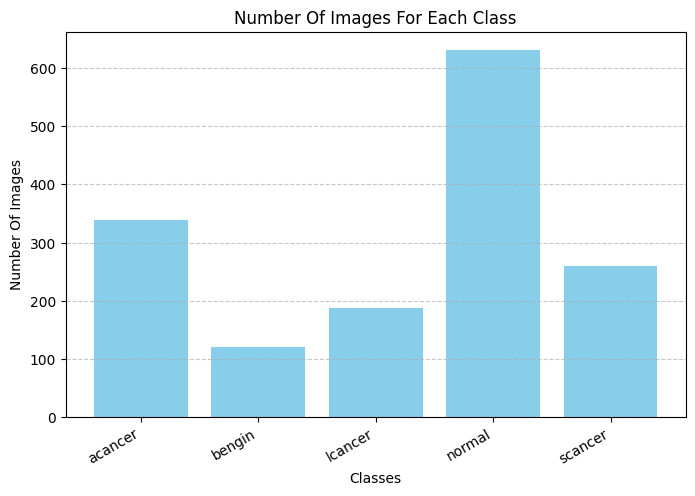

In [11]:
import os
import matplotlib.pyplot as plt
from collections import Counter

root_folder = r"C:\Dat\Research\Photo\Photo"  # Thay bằng đường dẫn thực tế

image_extensions = {".png", ".jpg", ".jpeg", ".gif", ".bmp", ".svg"}

folder_counts = Counter()

for subfolder in os.listdir(root_folder):
    subfolder_path = os.path.join(root_folder, subfolder)
    if os.path.isdir(subfolder_path):  # Kiểm tra nếu là thư mục
        count = sum(1 for file in os.listdir(subfolder_path) 
                    if os.path.splitext(file)[1].lower() in image_extensions)
        folder_counts[subfolder] = count

if folder_counts:
    labels, counts = zip(*folder_counts.items())

    plt.figure(figsize=(8, 5))
    plt.bar(labels, counts, color="skyblue")
    plt.xlabel("Classes")
    plt.ylabel("Number Of Images")
    plt.title("Number Of Images For Each Class")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()
else:
    print("Không tìm thấy ảnh nào trong thư mục con!")


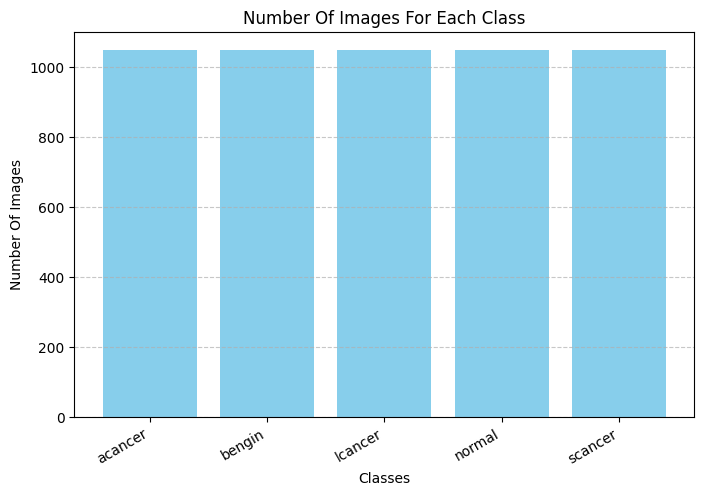

In [9]:
root_folder = r"C:\Dat\Research\Final\PhotoSmoteFinal"  # Thay bằng đường dẫn thực tế

image_extensions = {".png", ".jpg", ".jpeg", ".gif", ".bmp", ".svg"}

folder_counts = Counter()

for subfolder in os.listdir(root_folder):
    subfolder_path = os.path.join(root_folder, subfolder)
    if os.path.isdir(subfolder_path):  # Kiểm tra nếu là thư mục
        count = sum(1 for file in os.listdir(subfolder_path) 
                    if os.path.splitext(file)[1].lower() in image_extensions)
        folder_counts[subfolder] = count

if folder_counts:
    labels, counts = zip(*folder_counts.items())

    # Vẽ biểu đồ cột
    plt.figure(figsize=(8, 5))
    plt.bar(labels, counts, color="skyblue")
    plt.xlabel("Classes")
    plt.ylabel("Number Of Images")
    plt.title("Number Of Images For Each Class")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()
else:
    print("Không tìm thấy ảnh nào trong thư mục con!")


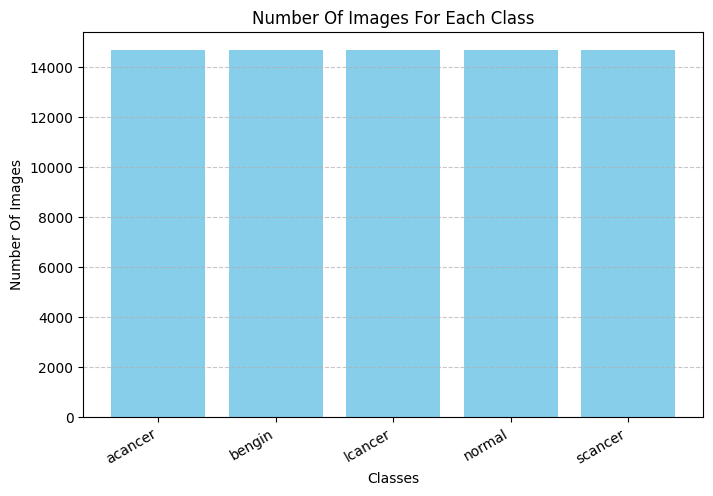

In [10]:
root_folder = r"C:\Dat\Research\Final\PhotoAgruFinal"  # Thay bằng đường dẫn thực tế

image_extensions = {".png", ".jpg", ".jpeg", ".gif", ".bmp", ".svg"}

folder_counts = Counter()

for subfolder in os.listdir(root_folder):
    subfolder_path = os.path.join(root_folder, subfolder)
    if os.path.isdir(subfolder_path):  # Kiểm tra nếu là thư mục
        count = sum(1 for file in os.listdir(subfolder_path) 
                    if os.path.splitext(file)[1].lower() in image_extensions)
        folder_counts[subfolder] = count

if folder_counts:
    labels, counts = zip(*folder_counts.items())

    plt.figure(figsize=(8, 5))
    plt.bar(labels, counts, color="skyblue")
    plt.xlabel("Classes")
    plt.ylabel("Number Of Images")
    plt.title("Number Of Images For Each Class")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()
else:
    print("Không tìm thấy ảnh nào trong thư mục con!")


Smote


In [2]:
import os
import numpy as np
from imblearn.over_sampling import SMOTE
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img
import gc  # Giải phóng bộ nhớ tạm thời

def smote(Before, Smote_save):
    imagegen = ImageDataGenerator()

    train_generator = imagegen.flow_from_directory(
        Before,
        class_mode="categorical",
        shuffle=False,
        batch_size=32,            # Giảm batch_size để tiết kiệm RAM
        target_size=(224, 224),
        seed=42
    )

    x, y = [], []
    for batch_x, batch_y in train_generator:
        x.append(batch_x)
        y.append(batch_y)

        gc.collect()

        if train_generator.batch_index == 0:
            break

    x = np.concatenate(x)
    y = np.concatenate(y)

    print("Kích thước ảnh:", x.shape)
    print("Kích thước nhãn:", y.shape)

    X_train = x.reshape(x.shape[0], 224 * 224 * 3)
    y_numeric = np.argmax(y, axis=1)

    sm = SMOTE(random_state=42)
    X_smote, y_smote = sm.fit_resample(X_train, y_numeric)

    Xsmote_img = X_smote.reshape(X_smote.shape[0], 224, 224, 3)

    label_map = {0: 'Lcancer', 1: 'Normal', 2: 'Bengin', 3: 'Acancer', 4: 'Scancer'}

    for label_name in label_map.values():
        os.makedirs(os.path.join(Smote_save, label_name), exist_ok=True)

    for i in range(len(Xsmote_img)):
        label_name = label_map.get(y_smote[i], 'Unknown')
        label_dir = os.path.join(Smote_save, label_name)

        pil_img = array_to_img(Xsmote_img[i] * 255)
        pil_img.save(os.path.join(label_dir, f'{label_name}_{i}.jpg'))

        del pil_img
        gc.collect()



In [3]:
smote( r'C:/Dat/Research/Final/PhotoFinal', r'C:/Dat/Research/Final/PhotoSmoteFinal')


Found 1952 images belonging to 5 classes.
Kích thước ảnh: (1952, 224, 224, 3)
Kích thước nhãn: (1952, 5)


Agru

In [22]:
def agru(dir, output_folder, input_folder):
    def agumentation(input_folder, output_name):
        for filename in os.listdir(input_folder):
            if filename.endswith(('.jpg', '.jpeg', '.png', 'bmp')):  # Kiểm tra định dạng ảnh
                img_path = os.path.join(input_folder, filename)
                img = cv2.imread(img_path)

                if img is None:
                    print(f"Skipping {filename}, unable to read the file.")
                    continue

                base_name, ext = os.path.splitext(filename)

                cv2.imwrite(os.path.join(output_name, f"{base_name}_original{ext}"), img)

                (h, w) = img.shape[:2]
                center = (w // 2, h // 2)
                angles = [45, -45, 30, -30, 20, -20]

                for angle in angles:
                    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 0.8)
                    rotated_img = cv2.warpAffine(img, rotation_matrix, (w, h))
                    cv2.imwrite(os.path.join(output_name, f"{base_name}_rotated_{angle}{ext}"), rotated_img)

                flipped_img = cv2.flip(img, 1)
                cv2.imwrite(os.path.join(output_name, f"{base_name}_flipped{ext}"), flipped_img)
                
                for angle in angles:
                    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 0.8)
                    flipped_rotated_img = cv2.warpAffine(flipped_img, rotation_matrix, (w, h))
                    cv2.imwrite(os.path.join(output_name, f"{base_name}_flipped_rotated_{angle}{ext}"), flipped_rotated_img)

                cv2.destroyAllWindows()

        print("Hoàn tất xử lý và lưu ảnh!")

    output_normal_folder = os.path.join(dir, output_folder, 'normal')
    output_scancer_folder = os.path.join(dir, output_folder, 'acancer')
    output_bengin_folder = os.path.join(dir, output_folder, 'bengin')
    output_lcancer_folder = os.path.join(dir, output_folder, 'lcancer')
    output_acancer_folder = os.path.join(dir, output_folder, 'scancer')

    os.makedirs(output_normal_folder, exist_ok=True)
    os.makedirs(output_lcancer_folder, exist_ok=True)
    os.makedirs(output_bengin_folder, exist_ok=True)
    os.makedirs(output_scancer_folder, exist_ok=True)
    os.makedirs(output_acancer_folder, exist_ok=True)

    input_folder_bengin = os.path.join(dir, input_folder, 'Bengin')
    r'C:/Dat/Research/Final/PhotoSmoteFinal/Bengin'
    output_name_bengin = output_bengin_folder
    agumentation(input_folder_bengin, output_name_bengin)

    input_folder_normal = os.path.join(dir, input_folder, 'Normal')
    r'C:/Dat/Research/Final/PhotoSmoteFinal/Normal'
    output_name_normal = output_normal_folder
    agumentation(input_folder_normal, output_name_normal)

    input_folder_acancer = os.path.join(dir, input_folder, 'Acancer')
    r'C:/Dat/Research/Final/PhotoSmoteFinal/Acancer'
    output_name_acancer = output_acancer_folder
    agumentation(input_folder_acancer, output_name_acancer)
    
    input_folder_lcancer = os.path.join(dir, input_folder, 'Lcancer')
    r'C:/Dat/Research/Final/PhotoSmoteFinal/Lcancer'
    output_name_lcancer = output_lcancer_folder
    agumentation(input_folder_lcancer, output_name_lcancer)
    
    input_folder_scancer = os.path.join(dir, input_folder, 'Scancer')
    r'C:/Dat/Research/Final/PhotoSmoteFinal/Scancer'
    output_name_scancer = output_scancer_folder
    agumentation(input_folder_scancer, output_name_scancer)
    
    
    

In [23]:
agru(r'C:/Dat/Research/Final', 'PhotoAgruFinal', 'PhotoSmoteFinal')

Hoàn tất xử lý và lưu ảnh!
Hoàn tất xử lý và lưu ảnh!
Hoàn tất xử lý và lưu ảnh!
Hoàn tất xử lý và lưu ảnh!
Hoàn tất xử lý và lưu ảnh!


**Preprocess**

In [ ]:
sharpen_kernel = np.array([[0, -1, 0], 
                           [-1, 5, -1], 
                           [0, -1, 0]])

def preprocess_images(input_folder, output_folder, target_size=(224, 224)):
    
    if not os.path.exists(input_folder):
        print(f"Lỗi")
        return
    
    os.makedirs(output_folder, exist_ok=True)

    for root, dirs, files in os.walk(input_folder):
        for filename in files:
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            
            input_path = os.path.join(root, filename)

            image = cv2.imread(input_path)
            if image is None:
                print(f"Can not read: {input_path}")
                continue
            
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            image = cv2.resize(image, target_size)

            sharpened = cv2.filter2D(image, -1, sharpen_kernel)

            lab = cv2.cvtColor(sharpened, cv2.COLOR_RGB2LAB)  
            l, a, b = cv2.split(lab)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            l = clahe.apply(l)  
            lab = cv2.merge((l, a, b))  
            enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)  

            relative_path = os.path.relpath(root, input_folder)
            save_subfolder = os.path.join(output_folder, relative_path)
            os.makedirs(save_subfolder, exist_ok=True)

            save_path = os.path.join(save_subfolder, filename)
            cv2.imwrite(save_path, cv2.cvtColor(enhanced, cv2.COLOR_RGB2BGR))

            print(f"Đã xử lý và lưu: {save_path}")

    print("🎉 Hoàn thành tiền xử lý tất cả ảnh!")

input_folder = r"C:/Dat/Research/Final/PhotoAgruFinal"  
output_folder = r"C:/Dat/Research/Final/PhotoFinal"  

preprocess_images(input_folder, output_folder)


**Devide**

In [27]:
os.chdir('C:/Dat/Research/Final/PhotoTrain')
if os.path.isdir('train/normal') is False:
    os.makedirs('train/normal')
    os.makedirs('train/bengin')
    os.makedirs('train/acancer')
    os.makedirs('train/lcancer')
    os.makedirs('train/scancer')
    os.makedirs('test/bengin')
    os.makedirs('test/acancer')
    os.makedirs('test/lcancer')
    os.makedirs('test/scancer')
    os.makedirs('test/normal')

In [26]:
os.chdir(r'C:/Dat/Research')
image_extensions = ('*.jpg', '*.jpeg', '*.png', '*.bmp')

def glob_image():
    def get_all_images(folder, extensions):
        images = []
        for ext in extensions:
            images.extend(glob.glob(os.path.join(folder, ext)))
        return images

    normal_images = get_all_images(r'C:/Dat/Research/Final/PhotoFinal/normal', image_extensions)
    bengin_images = get_all_images(r'C:/Dat/Research/Final/PhotoFinal/bengin', image_extensions)
    acancer_images = get_all_images(r'C:/Dat/Research/Final/PhotoFinal/acancer', image_extensions)
    lcancer_images = get_all_images(r'C:/Dat/Research/Final/PhotoFinal/lcancer', image_extensions)
    scancer_images = get_all_images(r'C:/Dat/Research/Final/PhotoFinal/scancer', image_extensions)

    return normal_images, bengin_images, acancer_images, lcancer_images, scancer_images

normal_images, bengin_images, acancer_images, lcancer_images, scancer_images = glob_image()

print(f"normal images: {len(normal_images)}")
print(f"bengin images: {len(bengin_images)}")
print(f"acancer images: {len(acancer_images)}")
print(f"lcancer images: {len(lcancer_images)}")
print(f"scancer images: {len(scancer_images)}")


for c in random.sample(normal_images, 10260 ):
    shutil.move(c, r'C:/Dat/Research/Final/PhotoTrain/train/normal')
for c in random.sample(bengin_images, 10260):
    shutil.move(c, r'C:/Dat/Research/Final/PhotoTrain/train/bengin')
for c in random.sample(acancer_images, 10260):
    shutil.move(c, r'C:/Dat/Research/Final/PhotoTrain/train/acancer')
for c in random.sample(lcancer_images, 10260):
    shutil.move(c, r'C:/Dat/Research/Final/PhotoTrain/train/lcancer')
for c in random.sample(scancer_images, 10260):
    shutil.move(c, r'C:/Dat/Research/Final/PhotoTrain/train/scancer')

normal_images, bengin_images, acancer_images, lcancer_images, scancer_images = glob_image()
for c in random.sample(normal_images, 4398 ):
    shutil.move(c, r'C:/Dat/Research/Final/PhotoTrain/test/normal')
for c in random.sample(bengin_images, 4398):
    shutil.move(c, r'C:/Dat/Research/Final/PhotoTrain/test/bengin')
for c in random.sample(acancer_images, 4398):
    shutil.move(c, r'C:/Dat/Research/Final/PhotoTrain/test/acancer')
for c in random.sample(lcancer_images, 4398):
    shutil.move(c, r'C:/Dat/Research/Final/PhotoTrain/test/lcancer')
for c in random.sample(scancer_images, 4398):
    shutil.move(c, r'C:/Dat/Research/Final/PhotoTrain/test/scancer')

os.chdir('../../')


normal images: 14658
bengin images: 14658
acancer images: 14658
lcancer images: 14658
scancer images: 14658
